**Bank Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Midterm /bank-additional-full.csv", sep=";")

**Exploratory Data Analysis**

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [5]:
df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.shape

(41188, 21)

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [8]:
df.select_dtypes(include = "object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [9]:
len(df.select_dtypes(include = "object").columns)

11

In [10]:
for col in df.select_dtypes('object').columns:
  print(f'\n\n{col}')
  print(f'Number of unique values: {df[col].nunique()}\n')
  display(df[col].value_counts())



job
Number of unique values: 12



,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060




marital
Number of unique values: 4



,count
marital,
married,24928
single,11568
divorced,4612
unknown,80




education
Number of unique values: 8



...

,count
day_of_week,
thu,8623
mon,8514
wed,8134
tue,8090
fri,7827




poutcome
Number of unique values: 3



,count
poutcome,
nonexistent,35563
failure,4252
success,1373




y
Number of unique values: 2



,count
y,
no,36548
yes,4640


In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [12]:
num_cols.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [13]:
len(df.select_dtypes(include=['int64', 'float64']).columns)

10

Our dataset consists of 41,188 rows and 21 columns, 11 of which are categorical and 10 are numerical.

In [14]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [15]:
df.isnull().values.any()

np.False_

The data frame contains no missing values (NaN / null).

In [16]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.89
yes,0.11


The dataset is imbalanced, with significantly more "no" than "yes" cases.

**Analysis of the effect of variables on y**

*   Analysis of numerical columns
*   Analysis of categorical columns



**Analysis of numerical columns**


In [17]:
import math

In [18]:
df['y'] = df['y'].map({'yes':1, 'no':0})

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

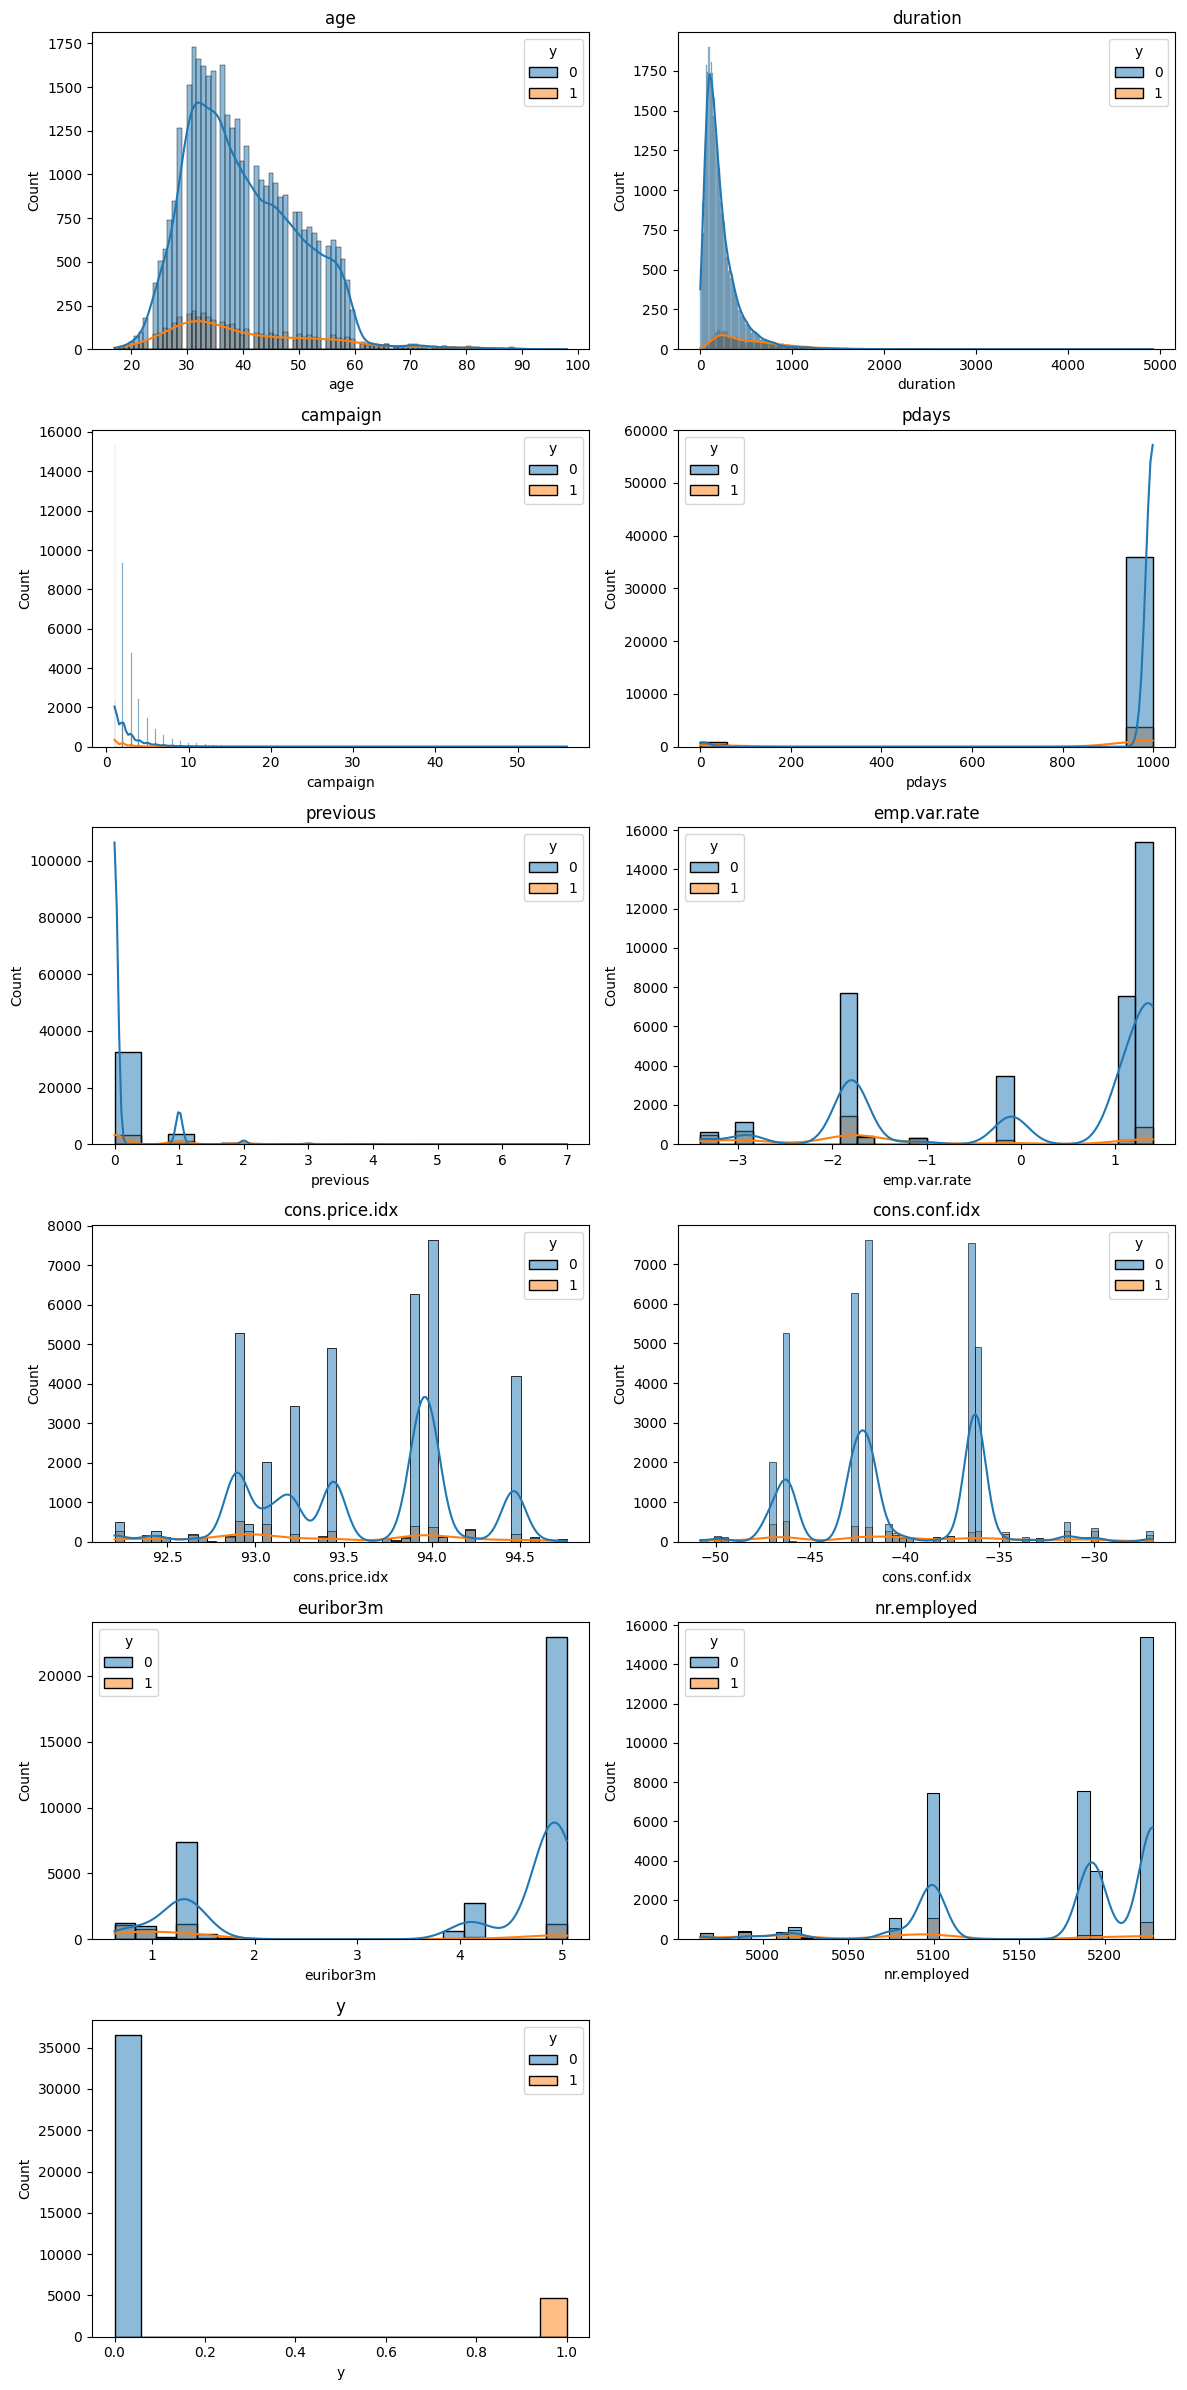

In [20]:
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='y', kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

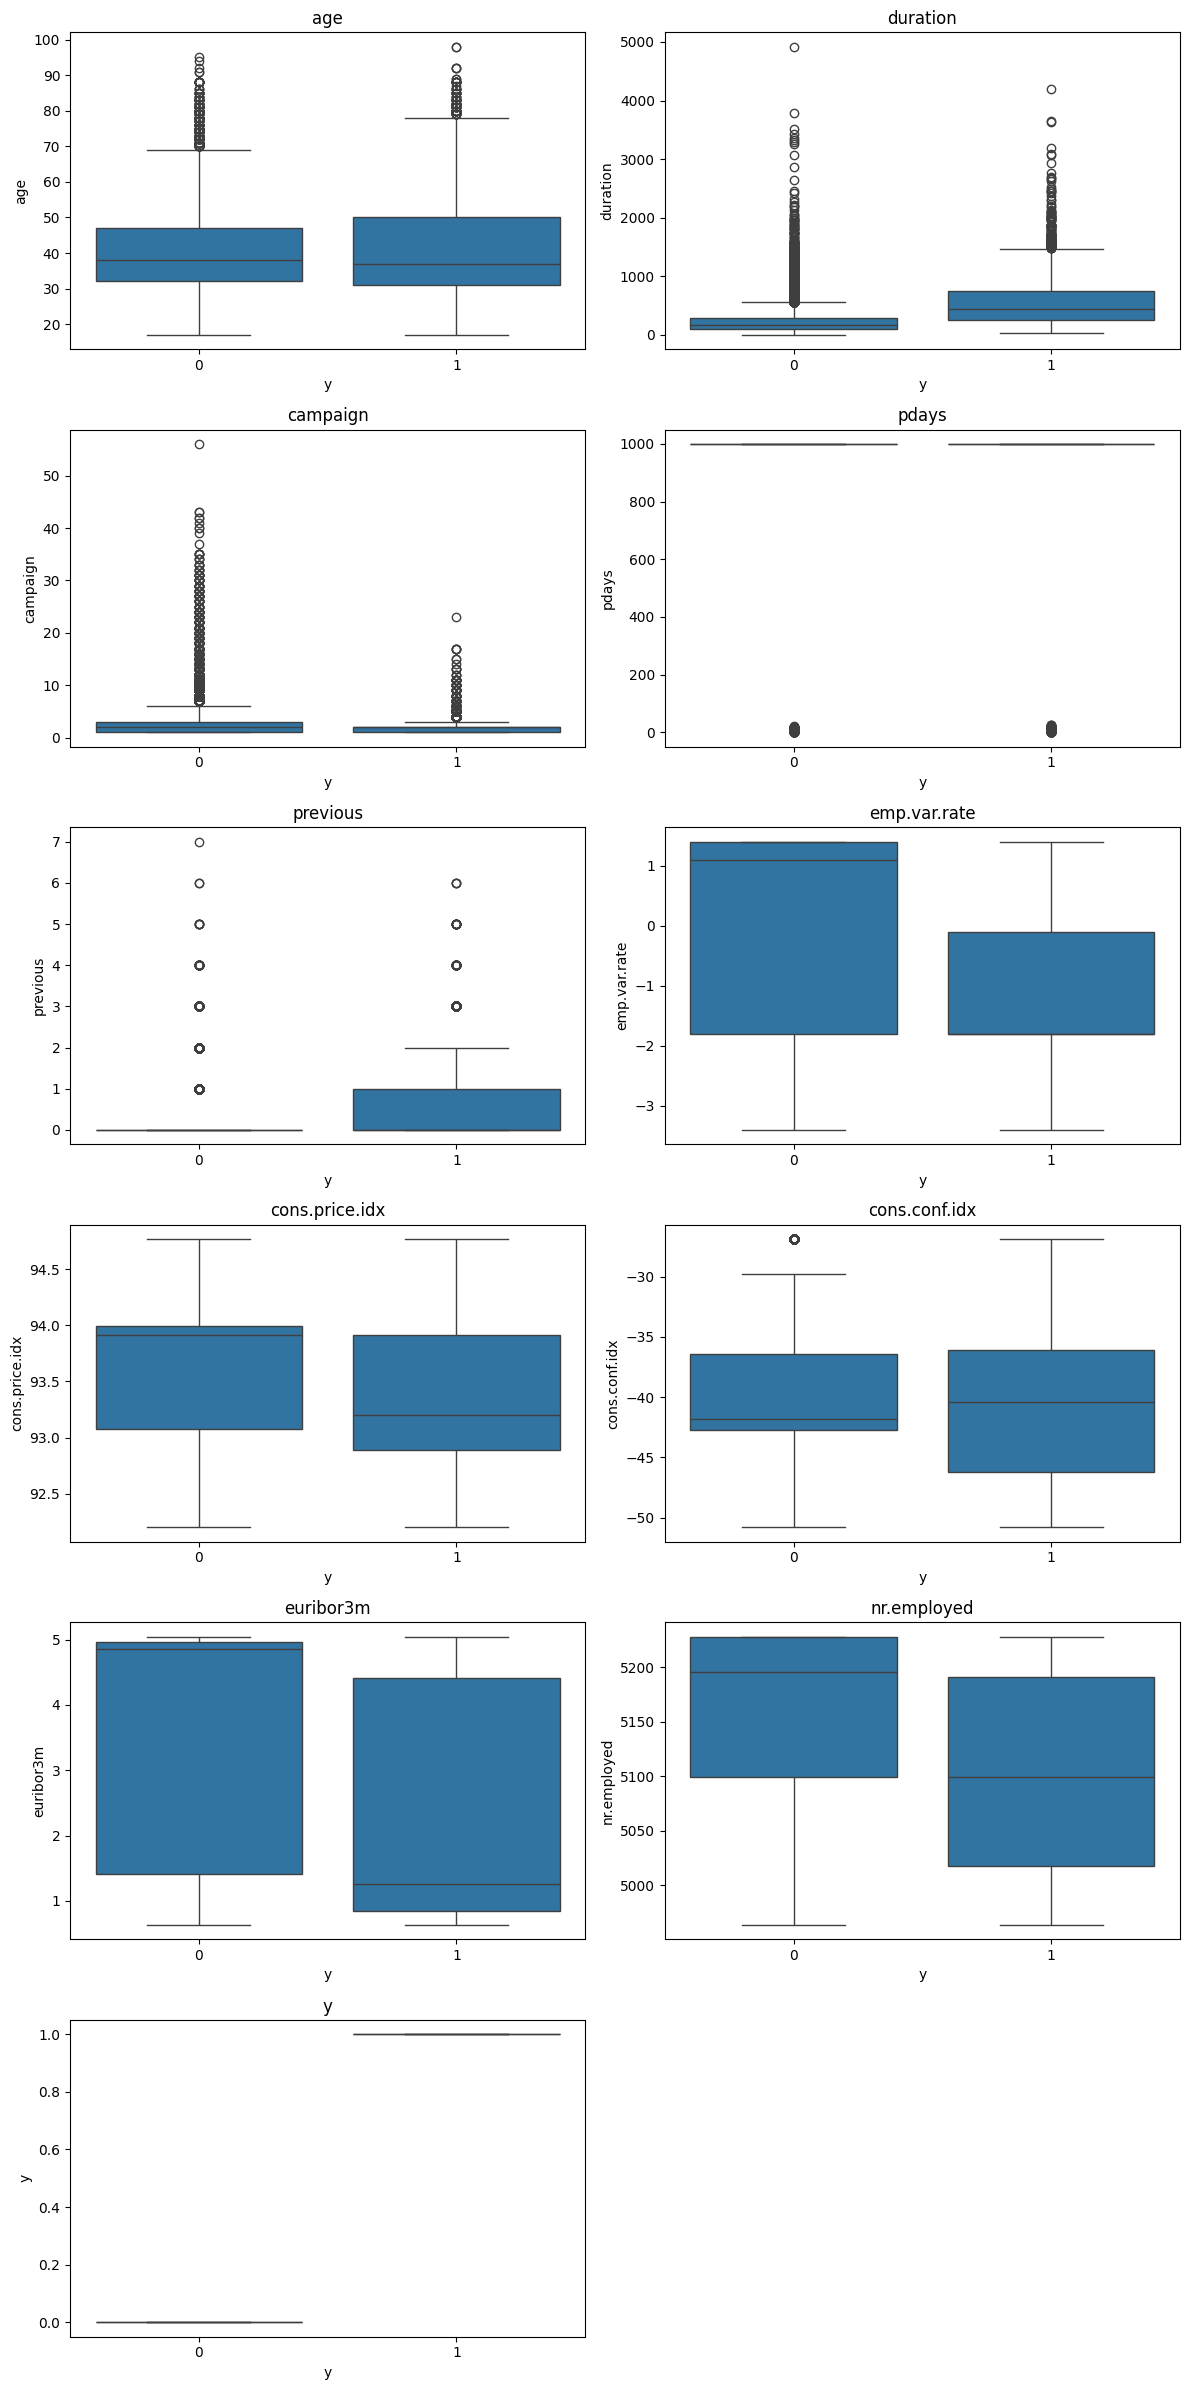

In [21]:
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
df['duration_bin'] = pd.cut(df['duration'], bins=[0,100,300,600,1000,5000])

df.groupby('duration_bin')['y'].mean()

/tmp/ipykernel_15471/1572448950.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('duration_bin')['y'].mean()


,y
duration_bin,
"(0, 100]",0.01
"(100, 300]",0.07
"(300, 600]",0.19
"(600, 1000]",0.45
"(1000, 5000]",0.59


<Axes: xlabel='log_duration', ylabel='Count'>

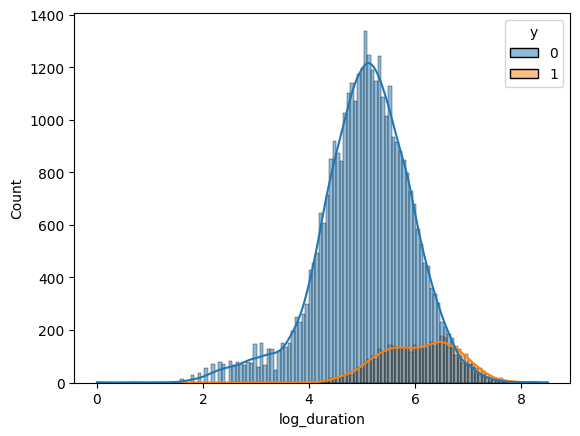

In [23]:
df['log_duration'] = np.log1p(df['duration'])

sns.histplot(data=df, x='log_duration', hue='y', kde=True)

Log transformation was applied to skewed features such as duration.
Although tree-based models are less sensitive to skewed distributions,
this transformation was considered to improve model robustness and
to support linear models.


In [24]:
df.groupby('campaign')['y'].mean().head(20)

,y
campaign,
1,0.13
2,0.11
3,0.11
4,0.09
5,0.08
6,0.08
7,0.06
8,0.04
9,0.06


<Axes: xlabel='campaign'>

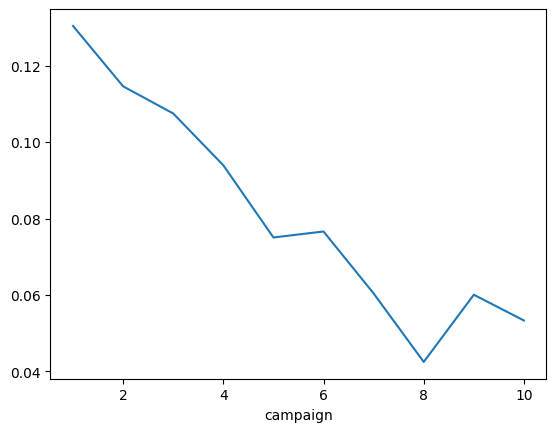

In [25]:
df.groupby('campaign')['y'].mean().head(10).plot()

The relationship between the number of contacts (campaign) and the target variable was analyzed.A clear decreasing trend is observed: the probability of subscription is highest at the first contact and declines significantly with additional contact attempts.For higher values of campaign, the results become unstable due to a small number of observations, which explains the fluctuations in the graph.
This suggests that repeated contact attempts have diminishing returns and are associated with lower conversion rates.

In [26]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

In [27]:
df.groupby('was_contacted_before')['y'].mean()

,y
was_contacted_before,
0,0.09
1,0.64


<Axes: xlabel='pdays', ylabel='Count'>

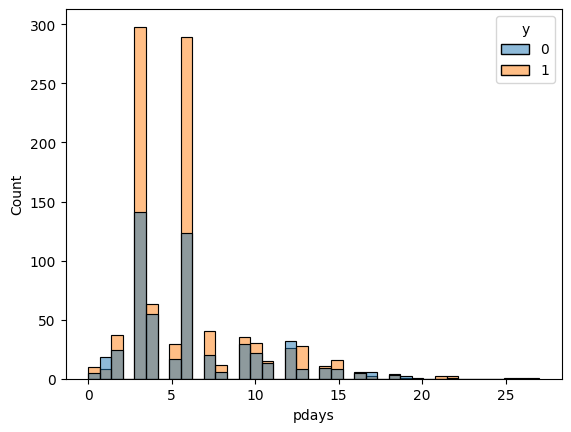

In [28]:
sns.histplot(data=df[df['pdays'] != 999], x='pdays', hue='y')

Further analysis was conducted on clients who were previously contacted (excluding the value 999).The results show that more recent contact (lower pdays values) is associated with a higher probability of subscription.
As the number of days since the last contact increases, the likelihood of a positive outcome decreases. This indicates a strong recency effect.

In [29]:
df['age_bin'] = pd.cut(df['age'], bins=[18,30,40,50,60,100])

df.groupby('age_bin')['y'].mean()

/tmp/ipykernel_15471/4050081639.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bin')['y'].mean()


,y
age_bin,
"(18, 30]",0.15
"(30, 40]",0.10
"(40, 50]",0.08
"(50, 60]",0.11
"(60, 100]",0.45


The relationship between age and the target variable was analyzed by grouping age into bins. The results show that middle-aged clients (30–50) have the lowest probability of subscription, while younger clients have slightly higher conversion rates. A significant increase is observed for clients aged 60 and above, indicating that older customers are much more likely to subscribe. This suggests that age has a non-linear relationship with the target variable and should be considered carefully in modeling.

In [30]:
df.groupby('previous')['y'].mean()

,y
previous,
0,0.09
1,0.21
2,0.46
3,0.59
4,0.54
5,0.72
6,0.60
7,0.00


In [31]:
df['had_previous_contact'] = (df['previous'] > 0).astype(int)

df.groupby('had_previous_contact')['y'].mean()

,y
had_previous_contact,
0,0.09
1,0.27


The previous feature represents the number of contacts performed before the current campaign.The majority of clients have no prior contact, which results in a highly skewed distribution. Analysis shows that clients who were previously contacted have a higher probability of subscription. However, due to the small number of observations for higher values, this feature is better interpreted as a binary indicator rather than a continuous variable.

<Axes: xlabel='campaign', ylabel='duration'>

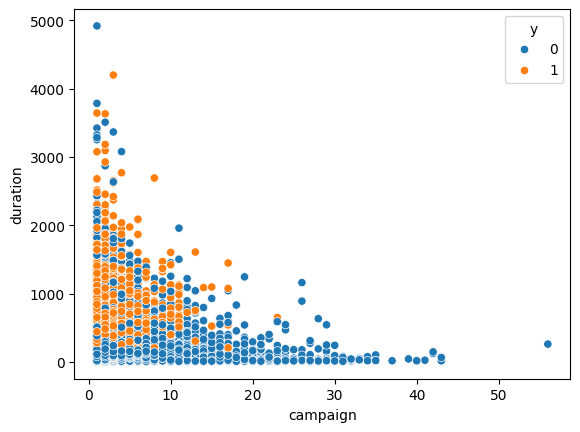

In [32]:
sns.scatterplot(data=df, x='campaign', y='duration', hue='y')

Frequent short calls have a negative impact and result in rejection.

<Axes: xlabel='age_bin', ylabel='campaign'>

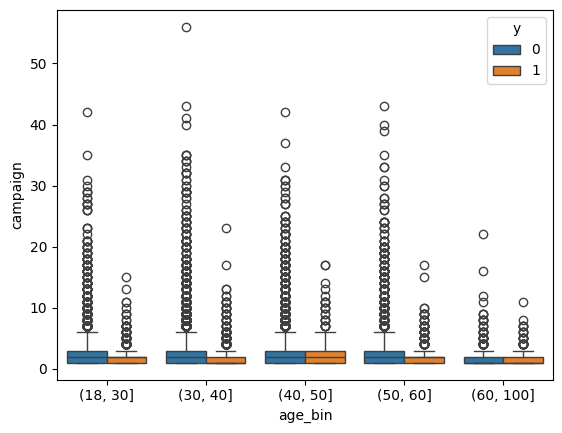

In [33]:
sns.boxplot(data=df, x='age_bin', y='campaign', hue='y')

The relationship between age groups, number of contacts (campaign), and the target variable was analyzed using boxplots.Across all age groups, successful cases (y=1) are associated with fewer contact attempts, while unsuccessful cases (y=0) often require multiple contacts.This pattern is consistent across age segments, indicating that the number of contact attempts is a strong predictor regardless of age.Additionally, a large number of outliers in the unsuccessful group suggests that repeated contact attempts are associated with low conversion probability.

**Analysis of categorical columns**

In [34]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

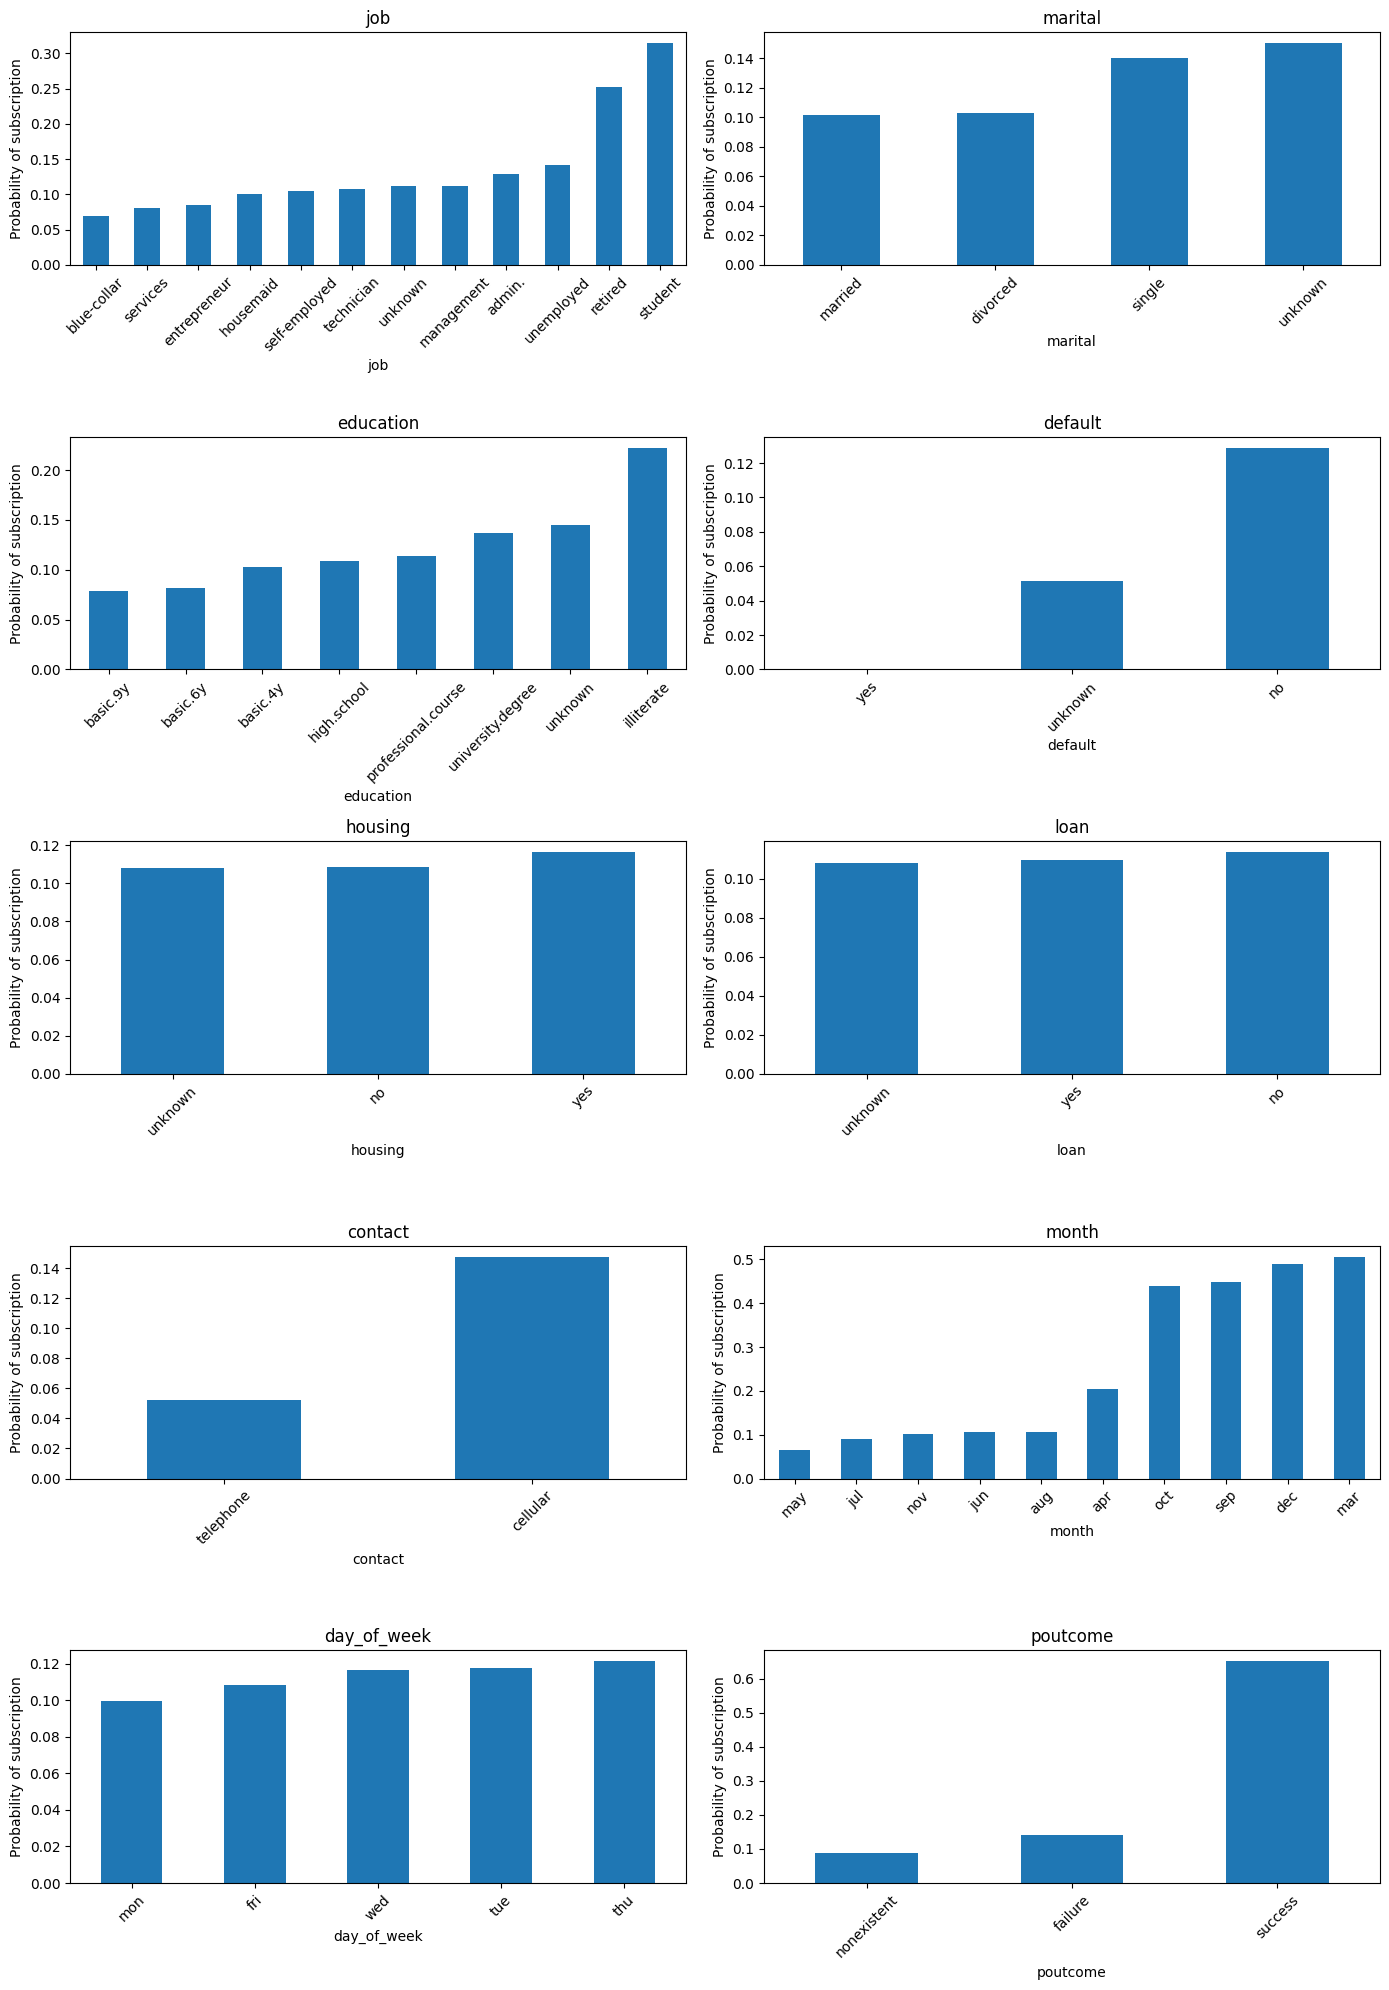

In [35]:
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby(col)['y'].mean().sort_values().plot(
        kind='bar', ax=axes[i]
    )
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Probability of subscription')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [36]:
df.groupby(col)['y'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
poutcome,,
success,0.65,1373
failure,0.14,4252
nonexistent,0.09,35563


Clients with a previous successful outcome have a very high probability of subscription (65%), compared to only 14% for those with a previous failure and 9% for clients with no previous contact.Additionally, the number of observations in each category is sufficiently large, making these results reliable.This indicates that past customer behavior is a strong predictor of future actions.

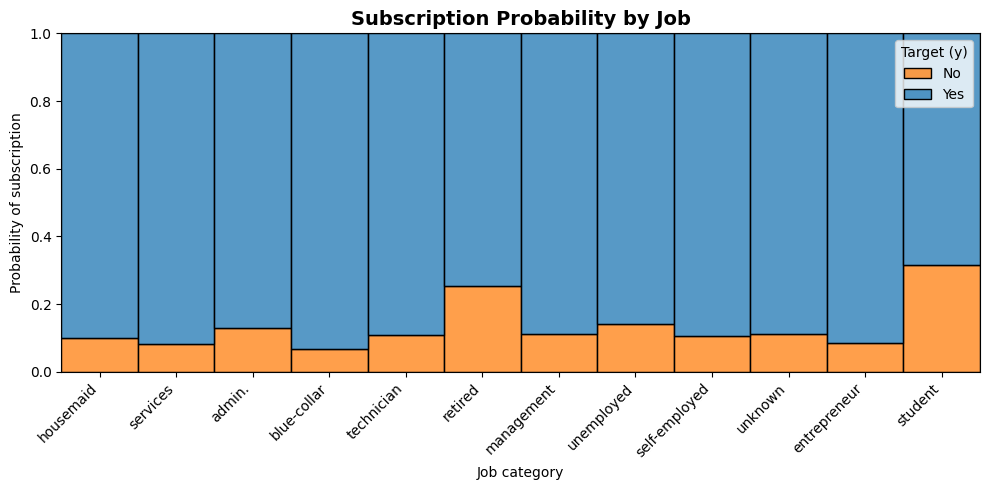

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='job',
    hue='y',
    multiple='fill'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Probability of subscription')
plt.xlabel('Job category')
plt.title('Subscription Probability by Job', fontsize=14, weight='bold')

plt.legend(title='Target (y)', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [38]:
df.groupby('job')['y'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
job,,
student,0.31,875
retired,0.25,1720
unemployed,0.14,1014
admin.,0.13,10422
management,0.11,2924
unknown,0.11,330
technician,0.11,6743
self-employed,0.10,1421
housemaid,0.10,1060


The analysis of the job feature shows significant differences in subscription probability across categories. These results should be interpreted together with the number of observations in each group. Categories with larger sample sizes (e.g. blue-collar, admin) provide more reliable estimates, while smaller groups (e.g. students) may be more sensitive to variability.
Students and retired clients represent the segments with the highest subscription probabilities.However, the retired group provides more reliable results due to a larger number of observations, while the student category should be interpreted with some caution.
Job title is an important criterion for customer segmentation.

In [39]:
df.groupby('education')['y'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
education,,
illiterate,0.22,18
unknown,0.15,1731
university.degree,0.14,12168
professional.course,0.11,5243
high.school,0.11,9515
basic.4y,0.10,4176
basic.6y,0.08,2292
basic.9y,0.08,6045


The education feature shows a clear trend in subscription probability.
Clients with higher education levels, such as university degrees, have higher conversion rates compared to those with basic education.
However, some categories (e.g. illiterate) have very few observations, making their results less reliable.
Education demonstrates a moderate but consistent influence on customer behavior.

/tmp/ipykernel_15471/160584624.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(values='y', index='age_bin', columns='contact'), annot=True)


<Axes: xlabel='contact', ylabel='age_bin'>

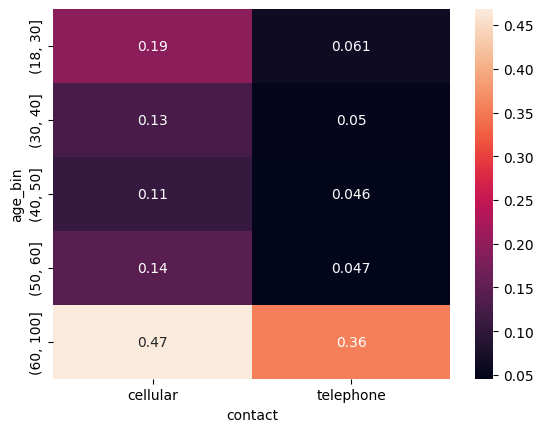

In [40]:
sns.heatmap(df.pivot_table(values='y', index='age_bin', columns='contact'), annot=True)

The contact feature represents the communication channel used to reach the client. Cellular refers to mobile phone contact, while telephone refers to landline communication. Analysis shows that cellular contact leads to significantly higher conversion rates. Cellular contact works better, and older clients are much more likely to convert.

In [41]:
df.groupby('month')['y'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
month,,
mar,0.51,546
dec,0.49,182
sep,0.45,570
oct,0.44,718
apr,0.20,2632
aug,0.11,6178
jun,0.11,5318
nov,0.10,4101
jul,0.09,7174


In [42]:
df.groupby('month')['campaign'].mean()

,campaign
month,
apr,1.95
aug,2.67
dec,2.16
jul,3.16
jun,3.07
mar,2.20
may,2.44
nov,1.91
oct,1.55


The month feature demonstrates a strong seasonal effect on subscription probability.Certain months (e.g. March, September, October, December) show significantly higher conversion rates, while others (e.g. May, July) have much lower performance.Additionally, the average number of contacts varies across months. Lower-performing months tend to have a higher number of contact attempts, suggesting that customers are less responsive and require repeated outreach. In contrast, high-performing months achieve higher conversion rates with fewer contact attempts, indicating more favorable conditions for customer engagement.This highlights the importance of campaign timing and its interaction with customer behavior.

**Statsmodel**

In [43]:
from scipy import stats

In [44]:
duration_yes = df[df['y'] == 1]['duration']
duration_no = df[df['y'] == 0]['duration']

t_stat, p_val = stats.ttest_ind(duration_yes, duration_no)
print(f"T-test for duration: p-value = {p_val}")

T-test for duration: p-value = 0.0


We reject the null hypothesis. This means that the “duration” variable does indeed have a statistically significant effect on whether a customer opens a deposit account.

In [45]:
contingency_table = pd.crosstab(df['poutcome'], df['y'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Хі-quadrat for poutcome: p-value = {p_val_chi2}")

Хі-quadrat for poutcome: p-value = 0.0


We reject the null hypothesis. This means that the “duration” variable does indeed have a statistically significant effect on whether a customer opens a deposit account.

In [46]:
categorical_vars = ['contact', 'month', 'education']
numerical_vars = ['campaign', 'previous', 'age']

print("--- Results of testing categorical variables ---")
for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['y'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    if (p < 0.05):
        status = "A statistically significant effect (p < 0.05)"
    else :
        status = "No effect was observed (p > 0.05)"
    print(f"Variable '{var}': p-value = {p:.10f} | {status}")

--- Results of testing categorical variables ---
Variable 'contact': p-value = 0.0000000000 | A statistically significant effect (p < 0.05)
Variable 'month': p-value = 0.0000000000 | A statistically significant effect (p < 0.05)
Variable 'education': p-value = 0.0000000000 | A statistically significant effect (p < 0.05)


In [47]:
print("\n--- Results of testing numerical characteristics ---")
for col in numerical_vars:
    group_yes = df[df['y'] == 1][col]
    group_no = df[df['y'] == 0][col]


    _, p_norm = stats.shapiro(df[col][:5000]) #  take a sample because the test is sensitive to large N


    stat, p_val = stats.mannwhitneyu(group_yes, group_no)

    print(f"\n--- Analysis for a variable: {col} ---")
    print(f"Normality (p-value): {p_norm:.4f}")
    print(f"Mann-Whitney U p-value: {p_val:.10f}")

    if p_val < 0.05:
        print(f"Result: A significant effect was found (p={p_val:.4f}).")
    else:
        print(f"Result: No significant effect was found (p={p_val:.4f}).")


--- Results of testing numerical characteristics ---

--- Analysis for a variable: campaign ---
Normality (p-value): 0.0000
Mann-Whitney U p-value: 0.0000000000
Result: A significant effect was found (p=0.0000).

--- Analysis for a variable: previous ---
Normality (p-value): 1.0000
Mann-Whitney U p-value: 0.0000000000
Result: A significant effect was found (p=0.0000).

--- Analysis for a variable: age ---
Normality (p-value): 0.0000
Mann-Whitney U p-value: 0.0160805383
Result: A significant effect was found (p=0.0161).


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


The features that have been analysed are statistically significant and have an impact; therefore, they must be included in the model

In [48]:
from scipy.stats import chi2_contingency

noise_candidates = ['day_of_week', 'loan', 'housing']

for var in noise_candidates:
    ct = pd.crosstab(df[var], df['y'])
    chi2, p, dof, ex = chi2_contingency(ct)
    print(f"Variable  '{var}': p-value = {p:.4f}")
    if p > 0.05:
        print(f"--> Null hypothesis H0 has been confirmed: {var} has NO effect on the result.")

Variable  'day_of_week': p-value = 0.0000
Variable  'loan': p-value = 0.5787
--> Null hypothesis H0 has been confirmed: loan has NO effect on the result.
Variable  'housing': p-value = 0.0583
--> Null hypothesis H0 has been confirmed: housing has NO effect on the result.


The features “day_of_week”, “loan” and “housing” are not statistically significant

This task is a binary classification problem with an imbalanced target variable, where the number of negative cases significantly exceeds the number of positive ones.
Therefore, accuracy is not an appropriate metric, as it may give misleading results by favoring the majority class.
The primary evaluation metric selected is ROC-AUC, as it measures the model's ability to distinguish between classes независимо від вибору порогу класифікації.
Additionally, F1-score can be used as a secondary metric to balance precision and recall, especially in cases where both false positives and false negatives are important.

**Preprocessing**

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [50]:
df_prep = df.copy()

df_prep = df_prep.drop(columns=['duration'], errors='ignore')
df_prep = df_prep.drop(columns=['log_duration'], errors='ignore')
df_prep = df_prep.drop(columns=['duration_bin'], errors='ignore')

The duration variable was excluded from the analysis because it is only known after the contact with the client, which would lead to data leakage. All preprocessing steps were performed without using this feature.

In [51]:
df_prep.replace('unknown', np.nan, inplace=True)

In [52]:
df_prep.isnull().values.any()

np.True_

In [53]:
df_prep.isnull().sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


All instances of ‘unknown’ are replaced with ‘nan’, so that they can later be replaced with the necessary data to improve the model

In [54]:
df_prep['was_contacted_before'] = (df_prep['pdays'] != 999).astype(int)
df_prep['had_previous_contact'] = (df_prep['previous'] > 0).astype(int)


New binary features were created to capture whether the client had been contacted previously and whether any prior interactions existed. These transformations simplify the original variables and make them more informative for the model.

In [55]:
education_map = {
    'basic.4y': 'basic',
    'basic.6y': 'basic',
    'basic.9y': 'basic',
    'high.school': 'high.school',
    'professional.course': 'professional',
    'university.degree': 'university',
    'illiterate': 'basic'
}
df_prep['education'] = df_prep['education'].replace(education_map)

In [56]:
job_map = {
    'admin.': 'white_collar',
    'management': 'white_collar',
    'technician': 'white_collar',
    'blue-collar': 'blue_collar',
    'services': 'blue_collar'
}
df_prep['job_group'] = df_prep['job'].replace(job_map)

Education and job categories were grouped to reduce sparsity and improve model stability. Similar levels of basic education and job were combined into a single category, allowing the model to capture more robust patterns.

In [57]:
df_prep['age_bin'] = pd.cut(
    df_prep['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18_30', '31_40', '41_50', '51_60', '60_plus']
)

The age variable was additionally transformed into categorical bins to capture non-linear relationships between age and the target variable. This allows the model to better distinguish between different age groups.

In [58]:
campaign_upper = df_prep['campaign'].quantile(0.95)
df_prep['campaign'] = np.where(
    df_prep['campaign'] > campaign_upper,
    campaign_upper,
    df_prep['campaign']
)

previous_upper = df_prep['previous'].quantile(0.95)
df_prep['previous'] = np.where(
    df_prep['previous'] > previous_upper,
    previous_upper,
    df_prep['previous']
)


In [59]:
X = df_prep.drop('y', axis=1)
y = df_prep['y']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)



Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_bin', 'job_group']
Numerical: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'had_previous_contact']


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [61]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (32950, 56)
Test shape: (8238, 56)


Categorical variables were encoded using OneHotEncoder within a preprocessing pipeline, ensuring consistent transformation of both training and test data.

In [62]:
print(type(X_train_processed))
print(X_train_processed.dtype)
print(np.issubdtype(X_train_processed.dtype, np.number))

<class 'numpy.ndarray'>
float64
True


In [63]:
feature_names = preprocessor.get_feature_names_out()

In [64]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_train_df.head()

,num__age,num__campaign,num__pdays,num__previous,num__emp.var.rate,num__cons.price.idx,num__cons.conf.idx,num__euribor3m,num__nr.employed,num__was_contacted_before,num__had_previous_contact,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__marital_married,cat__marital_single,cat__education_high.school,cat__education_professional,cat__education_university,cat__default_yes,cat__housing_yes,cat__loan_yes,cat__contact_telephone,cat__month_aug,cat__month_dec,cat__month_jul,cat__month_jun,cat__month_mar,cat__month_may,cat__month_nov,cat__month_oct,cat__month_sep,cat__day_of_week_mon,cat__day_of_week_thu,cat__day_of_week_tue,cat__day_of_week_wed,cat__poutcome_nonexistent,cat__poutcome_success,cat__age_bin_31_40,cat__age_bin_41_50,cat__age_bin_51_60,cat__age_bin_60_plus,cat__job_group_entrepreneur,cat__job_group_housemaid,cat__job_group_retired,cat__job_group_self-employed,cat__job_group_student,cat__job_group_unemployed,cat__job_group_white_collar
0,0.86,0.98,0.20,-0.40,-0.11,-0.65,-0.32,0.29,0.40,-0.20,-0.40,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,-0.29,-0.19,0.20,2.50,-0.11,-0.65,-0.32,0.29,0.40,-0.20,2.50,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3.65,-0.78,0.20,-0.40,-1.13,1.10,0.05,-1.58,-2.42,-0.20,-0.40,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
3,-0.39,-0.19,0.20,-0.40,0.65,0.72,0.89,0.71,0.33,-0.20,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4,1.82,-0.19,0.20,-0.40,-1.90,-1.06,-0.06,-1.36,-1.25,-0.20,-0.40,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00


In [65]:
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)
X_test_df.head()

,num__age,num__campaign,num__pdays,num__previous,num__emp.var.rate,num__cons.price.idx,num__cons.conf.idx,num__euribor3m,num__nr.employed,num__was_contacted_before,num__had_previous_contact,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__marital_married,cat__marital_single,cat__education_high.school,cat__education_professional,cat__education_university,cat__default_yes,cat__housing_yes,cat__loan_yes,cat__contact_telephone,cat__month_aug,cat__month_dec,cat__month_jul,cat__month_jun,cat__month_mar,cat__month_may,cat__month_nov,cat__month_oct,cat__month_sep,cat__day_of_week_mon,cat__day_of_week_thu,cat__day_of_week_tue,cat__day_of_week_wed,cat__poutcome_nonexistent,cat__poutcome_success,cat__age_bin_31_40,cat__age_bin_41_50,cat__age_bin_51_60,cat__age_bin_60_plus,cat__job_group_entrepreneur,cat__job_group_housemaid,cat__job_group_retired,cat__job_group_self-employed,cat__job_group_student,cat__job_group_unemployed,cat__job_group_white_collar
0,-0.77,1.57,0.20,-0.40,0.84,0.59,-0.47,0.77,0.84,-0.20,-0.40,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
1,-0.29,-0.78,0.20,-0.40,-1.90,-1.06,-0.06,-1.36,-1.25,-0.20,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2,3.17,-0.19,0.20,-0.40,-1.13,1.10,0.05,-1.62,-2.42,-0.20,-0.40,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
3,0.38,-0.19,0.20,-0.40,0.84,1.54,-0.28,0.77,0.84,-0.20,-0.40,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,-1.15,-0.19,0.20,-0.40,-1.20,-1.27,-2.05,-1.20,-0.94,-0.20,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


The transformed dataset was converted into a DataFrame to inspect the resulting features after preprocessing.

**Training models**

In [66]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

In [67]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )
}

performance_results = []



In [68]:
for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    performance_results.append({
        "Model": name,
        "F1-Score": f1_score(y_test, y_pred, pos_label=1),
        "Recall (Yes)": recall_score(y_test, y_pred, pos_label=1),
        "Precision (Yes)": precision_score(y_test, y_pred, pos_label=1),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    })

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))




--- Logistic Regression ---
              precision    recall  f1-score   support

          no       0.95      0.86      0.90      7310
         yes       0.36      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238


--- kNN ---
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7310
         yes       0.56      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238


--- Decision Tree ---
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7310
         yes       0.40      0.61      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted 

In [69]:
for name, model in models.items():
    model.fit(X_train_processed, y_train)


    y_pred_test = model.predict(X_test_processed)
    y_proba_test = model.predict_proba(X_test_processed)[:, 1]


    y_pred_train = model.predict(X_train_processed)
    y_proba_train = model.predict_proba(X_train_processed)[:, 1]

    print(f"\n===== {name} =====")

    print("\n--- TRAIN ---")
    print("ROC-AUC:", roc_auc_score(y_train, y_proba_train))
    print("F1:", f1_score(y_train, y_pred_train))

    print("\n--- TEST ---")
    print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))
    print("F1:", f1_score(y_test, y_pred_test))


===== Logistic Regression =====

--- TRAIN ---
ROC-AUC: 0.7939362114519131
F1: 0.4521095196336354

--- TEST ---
ROC-AUC: 0.801027981862352
F1: 0.4652427184466019

===== kNN =====

--- TRAIN ---
ROC-AUC: 0.9249082911041017
F1: 0.48928696873902355

--- TEST ---
ROC-AUC: 0.7419988118543328
F1: 0.3795309168443497

===== Decision Tree =====

--- TRAIN ---
ROC-AUC: 0.835730831806034
F1: 0.5131773139363273

--- TEST ---
ROC-AUC: 0.7736253773762912
F1: 0.48223350253807107

===== XGBoost =====

--- TRAIN ---
ROC-AUC: 0.8416363823590461
F1: 0.4350661807020909

--- TEST ---
ROC-AUC: 0.8109648450398603
F1: 0.38396299151888974


To evaluate overfitting, model performance was compared on training and test datasets.

Logistic Regression showed very stable performance with almost identical ROC-AUC scores on both datasets, indicating good generalization.

kNN demonstrated strong overfitting, with a large gap between training (0.92) and test (0.74) ROC-AUC scores, suggesting that the model memorizes the training data but fails to generalize.

Decision Tree showed moderate overfitting, with a small drop in performance from train to test.

XGBoost achieved the best balance between performance and generalization, with high ROC-AUC and a small difference between training and test results. Therefore, it can be considered the most reliable model for this task.

In [70]:
results_df = pd.DataFrame(performance_results).sort_values(by="ROC_AUC", ascending=False)
results_df = results_df.round(4)

print("--- Model comparison ---")
display(results_df)

--- Model comparison ---


,Model,F1-Score,Recall (Yes),Precision (Yes),ROC_AUC
3,XGBoost,0.38,0.27,0.67,0.81
0,Logistic Regression,0.47,0.65,0.36,0.80
2,Decision Tree,0.48,0.61,0.40,0.77
1,kNN,0.38,0.29,0.56,0.74


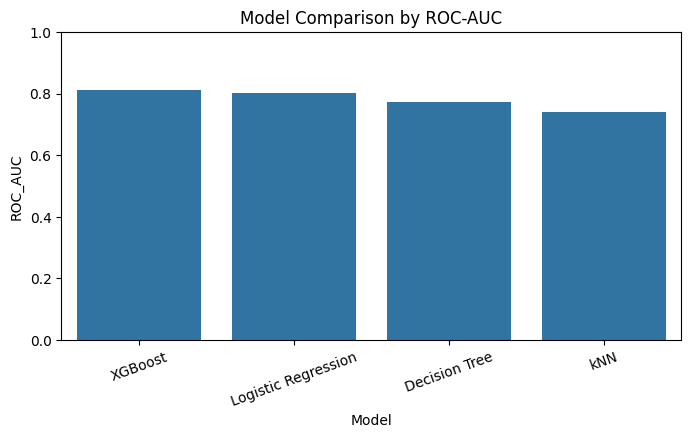

In [71]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Model', y='ROC_AUC')
plt.title('Model Comparison by ROC-AUC')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

ROC-AUC was chosen as the primary metric for model comparison because it evaluates the model’s ability to distinguish between classes independently of the classification threshold.
However, since the dataset is imbalanced and the goal is to correctly identify clients who are likely to subscribe, additional metrics such as Recall, Precision, and F1-score were also considered.
Recall is particularly important in this case, as missing a potential client (false negative) is more costly than contacting a non-interested one. Therefore, threshold tuning was applied to improve recall while maintaining a reasonable balance with precision using the F1-score.

In [72]:
xgb_model = models["XGBoost"]
y_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", round(best_threshold, 4))
print("Best F1:", round(f1_scores[best_idx], 4))
print("Precision:", round(precisions[best_idx], 4))
print("Recall:", round(recalls[best_idx], 4))

Best threshold: 0.2453
Best F1: 0.5337
Precision: 0.5
Recall: 0.5722


In [73]:
results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1],
    "f1": f1_scores
})

results.sort_values(by="f1", ascending=False).head(10)

,threshold,precision,recall,f1
6752,0.25,0.50,0.57,0.53
6751,0.24,0.50,0.57,0.53
6750,0.24,0.50,0.57,0.53
6746,0.24,0.50,0.57,0.53
6753,0.25,0.50,0.57,0.53
6749,0.24,0.50,0.57,0.53
6745,0.24,0.50,0.57,0.53
6748,0.24,0.50,0.57,0.53
6744,0.24,0.50,0.57,0.53
6747,0.24,0.50,0.57,0.53


The classification threshold was optimized using the Precision-Recall curve.
The threshold that maximized the F1-score was selected.

Additionally, alternative thresholds were analyzed to prioritize recall,
as missing potential clients is more critical than false positives.

This approach allowed improving model performance without retraining the model.

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
logreg = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
param_grid = [
    {
        'C': [0.01, 0.1, 1, 3, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    {
        'C': [0.01, 0.1, 1, 3, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }
]

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_processed, y_train)

best_logreg = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))



Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7894


In [76]:
y_train_proba = best_logreg.predict_proba(X_train_processed)[:, 1]
y_test_proba = best_logreg.predict_proba(X_test_processed)[:, 1]

train_roc_auc = roc_auc_score(y_train, y_train_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("\nTrain ROC-AUC:", round(train_roc_auc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))
print("Overfitting gap:", round(train_roc_auc - test_roc_auc, 4))





Train ROC-AUC: 0.7934
Test ROC-AUC: 0.8012
Overfitting gap: -0.0077


In [77]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nBest threshold:", round(best_threshold, 4))
print("Best F1 at threshold:", round(f1_scores[best_idx], 4))
print("Precision at best threshold:", round(precisions[best_idx], 4))
print("Recall at best threshold:", round(recalls[best_idx], 4))



Best threshold: 0.663
Best F1 at threshold: 0.512
Precision at best threshold: 0.4545
Recall at best threshold: 0.5862


In [78]:
y_train_pred = (y_train_proba >= best_threshold).astype(int)
y_test_pred = (y_test_proba >= best_threshold).astype(int)


results = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'F1': [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],
    'Precision': [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_train, y_train_proba),
        roc_auc_score(y_test, y_test_proba)
    ]
})

results = results.round(4)

print("\n=== Logistic Regression Results ===")
display(results)


print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred, target_names=['no', 'yes']))


=== Logistic Regression Results ===


,Dataset,F1,Recall,Precision,ROC-AUC
0,Train,0.48,0.55,0.43,0.79
1,Test,0.51,0.59,0.45,0.80



=== Classification Report (Test) ===
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      7310
         yes       0.45      0.59      0.51       928

    accuracy                           0.87      8238
   macro avg       0.70      0.75      0.72      8238
weighted avg       0.89      0.87      0.88      8238



In [79]:
threshold_results = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall': recalls[:-1],
    'f1': f1_scores
}).sort_values(by='f1', ascending=False)

print("\n=== Top thresholds by F1 ===")
display(threshold_results.head(10).round(4))


=== Top thresholds by F1 ===


,threshold,precision,recall,f1
6869,0.66,0.45,0.59,0.51
6872,0.66,0.45,0.59,0.51
6868,0.66,0.45,0.59,0.51
6871,0.66,0.45,0.59,0.51
6867,0.66,0.45,0.59,0.51
6873,0.66,0.45,0.58,0.51
6870,0.66,0.45,0.59,0.51
6866,0.66,0.45,0.59,0.51
6865,0.66,0.45,0.59,0.51
6861,0.66,0.45,0.59,0.51


Logistic Regression was improved by tuning hyperparameters using GridSearchCV.
Additionally, the classification threshold was optimized based on the F1-score
to achieve a better balance between precision and recall.

**Comparing table**

In [80]:
results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    y_train_proba = model.predict_proba(X_train_processed)[:, 1]
    y_test_proba = model.predict_proba(X_test_processed)[:, 1]


    train_roc = roc_auc_score(y_train, y_train_proba)
    test_roc = roc_auc_score(y_test, y_test_proba)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)

    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)

    gap = train_roc - test_roc

    if gap > 0.10:
        comment = "Strong overfitting, not recommended"
    elif gap > 0.05:
        comment = "Slight overfitting, acceptable but needs tuning"
    else:
        comment = "Good generalization"

    if name == "XGBoost":
        comment += "; best overall ROC-AUC. Good candidate for final solution and further hyperparameter tuning."
    elif name == "Logistic Regression":
        comment += "; stable and interpretable, good candidate. Suitable as a baseline and useful when interpretability is important."
    elif name == "Decision Tree":
        comment += "; easy to interpret, but weaker than ensembles.Could be improved by tuning tree depth"
    elif name == "kNN":
        comment += "; sensitive to overfitting and noise. Not recommended without additional tuning"

    results.append({
        "Model": name,
        "Hyperparameters": str(model.get_params()),
        "Train ROC-AUC": train_roc,
        "Validation ROC-AUC": test_roc,
        "Train F1": train_f1,
        "Validation F1": test_f1,
        "Train Recall": train_recall,
        "Validation Recall": test_recall,
        "Train Precision": train_precision,
        "Validation Precision": test_precision,
        "Overfitting Gap": gap,
        "Comment": comment
    })

results_df = pd.DataFrame(results).sort_values(by="Validation ROC-AUC", ascending=False)
results_df = results_df.round(4)
print("===Comparing table===")

display(results_df)

===Comparing table===


,Model,Hyperparameters,Train ROC-AUC,Validation ROC-AUC,Train F1,Validation F1,Train Recall,Validation Recall,Train Precision,Validation Precision,Overfitting Gap,Comment
3,XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.84,0.81,0.44,0.38,0.31,0.27,0.76,0.67,0.03,Good generalization; best overall ROC-AUC. Goo...
0,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced', 'dual':...",0.79,0.80,0.45,0.47,0.62,0.65,0.35,0.36,-0.01,"Good generalization; stable and interpretable,..."
2,Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',...",0.84,0.77,0.51,0.48,0.66,0.61,0.42,0.40,0.06,"Slight overfitting, acceptable but needs tunin..."
1,kNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.92,0.74,0.49,0.38,0.38,0.29,0.70,0.56,0.18,"Strong overfitting, not recommended; sensitive..."


In [106]:
results_df.to_csv("model_comparison.csv", index=False)
print("CSV saved as model_comparison.csv")

CSV saved as model_comparison.csv


**Procedure for tuning hyperparameters**

In [82]:
from sklearn.model_selection import RandomizedSearchCV

In [83]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

best_xgb_random = random_search.best_estimator_

print("Best params (RandomizedSearchCV):")
print(random_search.best_params_)

print("Best CV ROC-AUC:", round(random_search.best_score_, 4))

y_train_proba_random = best_xgb_random.predict_proba(X_train_processed)[:, 1]
y_test_proba_random = best_xgb_random.predict_proba(X_test_processed)[:, 1]

y_train_pred_random = best_xgb_random.predict(X_train_processed)
y_test_pred_random = best_xgb_random.predict(X_test_processed)

print("\n--- Random Search XGBoost ---")
print("Train ROC-AUC:", round(roc_auc_score(y_train, y_train_proba_random), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba_random), 4))
print("Train F1:", round(f1_score(y_train, y_train_pred_random), 4))
print("Test F1:", round(f1_score(y_test, y_test_pred_random), 4))
print("Train Recall:", round(recall_score(y_train, y_train_pred_random), 4))
print("Test Recall:", round(recall_score(y_test, y_test_pred_random), 4))
print("Train Precision:", round(precision_score(y_train, y_train_pred_random), 4))
print("Test Precision:", round(precision_score(y_test, y_test_pred_random), 4))

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_random, target_names=['no', 'yes']))

scale_pos_weight: 7.88
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params (RandomizedSearchCV):
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.7964

--- Random Search XGBoost ---
Train ROC-AUC: 0.8246
Test ROC-AUC: 0.8141
Train F1: 0.4723
Test F1: 0.4873
Train Recall: 0.646
Test Recall: 0.6606
Train Precision: 0.3722
Test Precision: 0.386

Classification report (test):
              precision    recall  f1-score   support

          no       0.95      0.87      0.91      7310
         yes       0.39      0.66      0.49       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238



In [84]:
!pip install hyperopt

In [85]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [86]:
space = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300, 500]),
    'learning_rate': hp.choice('learning_rate', [0.01, 0.03, 0.05, 0.1, 0.2]),
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 8]),
    'min_child_weight': hp.choice('min_child_weight', [1, 3, 5, 7]),
    'subsample': hp.choice('subsample', [0.6, 0.7, 0.8, 0.9, 1.0]),
    'colsample_bytree': hp.choice('colsample_bytree', [0.6, 0.7, 0.8, 0.9, 1.0]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1]),
    'reg_alpha': hp.choice('reg_alpha', [0, 0.01, 0.1, 1]),
    'reg_lambda': hp.choice('reg_lambda', [0.1, 1, 5, 10])
}

def objective(params):
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        **params
    )

    score = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=25,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print("Best indices from Hyperopt:")
print(best)

100%|██████████| 25/25 [03:03<00:00,  7.34s/trial, best loss: -0.7960831032965697]
Best indices from Hyperopt:
{'colsample_bytree': np.int64(0), 'gamma': np.int64(1), 'learning_rate': np.int64(0), 'max_depth': np.int64(1), 'min_child_weight': np.int64(1), 'n_estimators': np.int64(3), 'reg_alpha': np.int64(1), 'reg_lambda': np.int64(3), 'subsample': np.int64(0)}


In [87]:
best_params_hyperopt = {
    'n_estimators': [100, 200, 300, 500][best['n_estimators']],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2][best['learning_rate']],
    'max_depth': [3, 4, 5, 6, 8][best['max_depth']],
    'min_child_weight': [1, 3, 5, 7][best['min_child_weight']],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0][best['subsample']],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0][best['colsample_bytree']],
    'gamma': [0, 0.1, 0.3, 0.5, 1][best['gamma']],
    'reg_alpha': [0, 0.01, 0.1, 1][best['reg_alpha']],
    'reg_lambda': [0.1, 1, 5, 10][best['reg_lambda']]
}

print("Best params (Hyperopt):")
print(best_params_hyperopt)

Best params (Hyperopt):
{'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.6, 'colsample_bytree': 0.6, 'gamma': 0.1, 'reg_alpha': 0.01, 'reg_lambda': 10}


In [88]:
best_xgb_hyperopt = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    **best_params_hyperopt
)

best_xgb_hyperopt.fit(X_train_processed, y_train)

y_train_proba_h = best_xgb_hyperopt.predict_proba(X_train_processed)[:, 1]
y_test_proba_h = best_xgb_hyperopt.predict_proba(X_test_processed)[:, 1]

y_train_pred_h = best_xgb_hyperopt.predict(X_train_processed)
y_test_pred_h = best_xgb_hyperopt.predict(X_test_processed)

print("\n--- Hyperopt XGBoost ---")
print("Train ROC-AUC:", round(roc_auc_score(y_train, y_train_proba_h), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba_h), 4))
print("Train F1:", round(f1_score(y_train, y_train_pred_h), 4))
print("Test F1:", round(f1_score(y_test, y_test_pred_h), 4))
print("Train Recall:", round(recall_score(y_train, y_train_pred_h), 4))
print("Test Recall:", round(recall_score(y_test, y_test_pred_h), 4))
print("Train Precision:", round(precision_score(y_train, y_train_pred_h), 4))
print("Test Precision:", round(precision_score(y_test, y_test_pred_h), 4))

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_h, target_names=['no', 'yes']))


--- Hyperopt XGBoost ---
Train ROC-AUC: 0.813
Test ROC-AUC: 0.8123
Train F1: 0.4618
Test F1: 0.4751
Train Recall: 0.6409
Test Recall: 0.6584
Train Precision: 0.3609
Test Precision: 0.3717

Classification report (test):
              precision    recall  f1-score   support

          no       0.95      0.86      0.90      7310
         yes       0.37      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.66      0.76      0.69      8238
weighted avg       0.89      0.84      0.85      8238



In [89]:
comparison_boosting = pd.DataFrame([
    {
        "Method": "RandomizedSearchCV",
        "Best Parameters": str(random_search.best_params_),
        "Train ROC-AUC": roc_auc_score(y_train, y_train_proba_random),
        "Validation ROC-AUC": roc_auc_score(y_test, y_test_proba_random),
        "Train F1": f1_score(y_train, y_train_pred_random),
        "Validation F1": f1_score(y_test, y_test_pred_random),
        "Train Recall": recall_score(y_train, y_train_pred_random),
        "Validation Recall": recall_score(y_test, y_test_pred_random),
        "Train Precision": precision_score(y_train, y_train_pred_random),
        "Validation Precision": precision_score(y_test, y_test_pred_random)
    },
    {
        "Method": "Hyperopt",
        "Best Parameters": str(best_params_hyperopt),
        "Train ROC-AUC": roc_auc_score(y_train, y_train_proba_h),
        "Validation ROC-AUC": roc_auc_score(y_test, y_test_proba_h),
        "Train F1": f1_score(y_train, y_train_pred_h),
        "Validation F1": f1_score(y_test, y_test_pred_h),
        "Train Recall": recall_score(y_train, y_train_pred_h),
        "Validation Recall": recall_score(y_test, y_test_pred_h),
        "Train Precision": precision_score(y_train, y_train_pred_h),
        "Validation Precision": precision_score(y_test, y_test_pred_h)
    }
]).round(4)

display(comparison_boosting)

,Method,Best Parameters,Train ROC-AUC,Validation ROC-AUC,Train F1,Validation F1,Train Recall,Validation Recall,Train Precision,Validation Precision
0,RandomizedSearchCV,"{'subsample': 0.9, 'reg_lambda': 10, 'reg_alph...",0.82,0.81,0.47,0.49,0.65,0.66,0.37,0.39
1,Hyperopt,"{'n_estimators': 500, 'learning_rate': 0.01, '...",0.81,0.81,0.46,0.48,0.64,0.66,0.36,0.37


Hyperparameter tuning for the XGBoost model was performed using two approaches: RandomizedSearchCV and Hyperopt (Bayesian Optimization).
Both methods achieved very similar performance, with identical ROC-AUC scores of 0.81 on the validation dataset, indicating comparable ability to distinguish between classes.
However, RandomizedSearchCV showed slightly better results in terms of F1-score and precision, while recall remained the same for both models. This suggests that RandomizedSearchCV provides a slightly better balance between precision and recall.
Overall, both methods are effective, but RandomizedSearchCV performed marginally better in this case. This may indicate that the defined parameter search space was sufficient, and Bayesian optimization did not provide a significant advantage.

**The importance of features for the model**

In [90]:
feature_names = preprocessor.get_feature_names_out()

importances = best_xgb_random.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(20)

,feature,importance
8,num__nr.employed,0.41
4,num__emp.var.rate,0.08
6,num__cons.conf.idx,0.05
9,num__was_contacted_before,0.04
37,cat__month_oct,0.04
35,cat__month_may,0.03
7,num__euribor3m,0.03
44,cat__poutcome_success,0.02
2,num__pdays,0.02
5,num__cons.price.idx,0.02


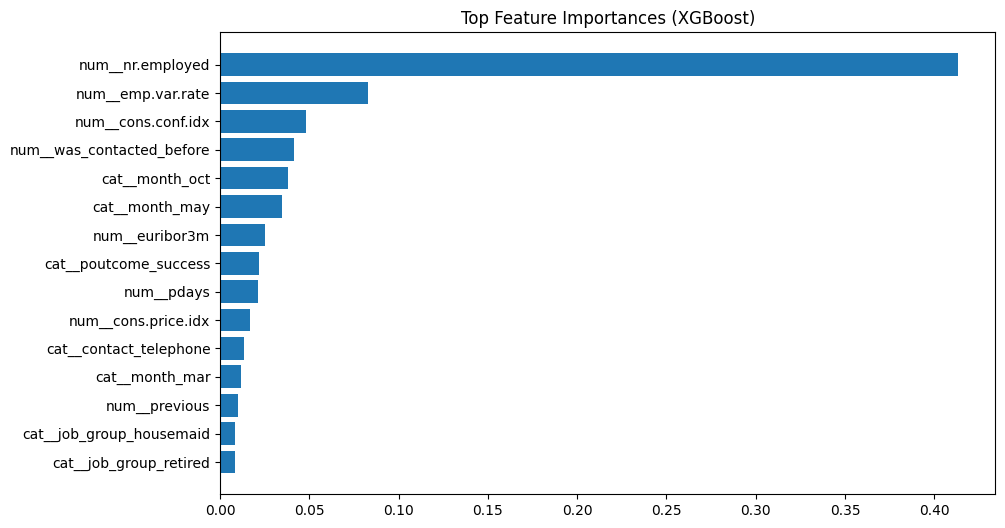

In [91]:
top_n = 15

feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(feat_imp_top["feature"], feat_imp_top["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (XGBoost)")
plt.show()

Feature importance analysis shows that the most influential variable is nr.employed, followed by other economic indicators such as emp.var.rate and cons.conf.idx.
Economic conditions have a strong impact on customer decisions, as people are more likely to subscribe to financial products when the economy is stable.

The feature was_contacted_before also has relatively high importance, which is logical since previous interaction with a client increases the likelihood of conversion.

Additionally, temporal features such as month (e.g., October and May) appear among the top predictors, suggesting that the timing of contact influences customer behavior.

The variable euribor3m (interest rate) also contributes to the model, which is expected, as financial conditions affect investment decisions.

The importance of poutcome_success is particularly meaningful, as a successful previous campaign strongly increases the probability of a positive response.

Overall, the feature importance ranking appears consistent with domain knowledge and reflects realistic relationships in customer behavior.

**Improving logistic regression**

In [92]:
from sklearn.model_selection import StratifiedKFold


In [93]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg = LogisticRegression(
    max_iter=10000,
    class_weight='balanced',
    random_state=42
)

param_grid = [
    {
        "C": [0.001, 0.01, 0.1, 1, 3, 10, 30, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    {
        "C": [0.001, 0.01, 0.1, 1, 3, 10, 30, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "newton-cg"]
    }
]

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_processed, y_train)

best_logreg = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))



Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7888


In [94]:
y_train_proba = best_logreg.predict_proba(X_train_processed)[:, 1]
y_test_proba = best_logreg.predict_proba(X_test_processed)[:, 1]

train_roc_auc = roc_auc_score(y_train, y_train_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC:", round(train_roc_auc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))
print("Overfitting gap:", round(train_roc_auc - test_roc_auc, 4))



Train ROC-AUC: 0.7934
Test ROC-AUC: 0.8012
Overfitting gap: -0.0077


In [95]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
    precisions[:-1] + recalls[:-1] + 1e-9
)

best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print("Best threshold by F1:", round(best_threshold_f1, 4))
print("Best F1:", round(f1_scores[best_idx], 4))
print("Precision at best F1 threshold:", round(precisions[best_idx], 4))
print("Recall at best F1 threshold:", round(recalls[best_idx], 4))



Best threshold by F1: 0.663
Best F1: 0.512
Precision at best F1 threshold: 0.4545
Recall at best F1 threshold: 0.5862


In [96]:
target_recall = 0.75
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_recall_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])]
    best_threshold_recall = thresholds[best_recall_idx]

    print("Best threshold with Recall >= 0.75:", round(best_threshold_recall, 4))
    print("Precision at Recall>=0.75 threshold:", round(precisions[best_recall_idx], 4))
    print("Recall at Recall>=0.75 threshold:", round(recalls[best_recall_idx], 4))
else:
    best_threshold_recall = best_threshold_f1
    print("\nNo threshold found with Recall >= 0.75, using F1-optimal threshold.")



Best threshold with Recall >= 0.75: 0.3758
Precision at Recall>=0.75 threshold: 0.2497
Recall at Recall>=0.75 threshold: 0.75


In [97]:
y_train_pred_f1 = (y_train_proba >= best_threshold_f1).astype(int)
y_test_pred_f1 = (y_test_proba >= best_threshold_f1).astype(int)

y_train_pred_rec = (y_train_proba >= best_threshold_recall).astype(int)
y_test_pred_rec = (y_test_proba >= best_threshold_recall).astype(int)

results_lr = pd.DataFrame([
    {
        "Version": "LogReg tuned + threshold(F1) - Train",
        "F1": f1_score(y_train, y_train_pred_f1),
        "Recall": recall_score(y_train, y_train_pred_f1),
        "Precision": precision_score(y_train, y_train_pred_f1),
        "ROC-AUC": roc_auc_score(y_train, y_train_proba)
    },
    {
        "Version": "LogReg tuned + threshold(F1) - Test",
        "F1": f1_score(y_test, y_test_pred_f1),
        "Recall": recall_score(y_test, y_test_pred_f1),
        "Precision": precision_score(y_test, y_test_pred_f1),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba)
    },
    {
        "Version": "LogReg tuned + threshold(Recall>=0.75) - Train",
        "F1": f1_score(y_train, y_train_pred_rec),
        "Recall": recall_score(y_train, y_train_pred_rec),
        "Precision": precision_score(y_train, y_train_pred_rec),
        "ROC-AUC": roc_auc_score(y_train, y_train_proba)
    },
    {
        "Version": "LogReg tuned + threshold(Recall>=0.75) - Test",
        "F1": f1_score(y_test, y_test_pred_rec),
        "Recall": recall_score(y_test, y_test_pred_rec),
        "Precision": precision_score(y_test, y_test_pred_rec),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba)
    }
]).round(4)

print("\n=== Logistic Regression improved results ===")
display(results_lr)



=== Logistic Regression improved results ===


,Version,F1,Recall,Precision,ROC-AUC
0,LogReg tuned + threshold(F1) - Train,0.48,0.55,0.43,0.79
1,LogReg tuned + threshold(F1) - Test,0.51,0.59,0.45,0.80
2,LogReg tuned + threshold(Recall>=0.75) - Train,0.37,0.73,0.24,0.79
3,LogReg tuned + threshold(Recall>=0.75) - Test,0.37,0.75,0.25,0.80


In [98]:
print("=== Classification report: threshold optimized for F1 ===")
print(classification_report(y_test, y_test_pred_f1, target_names=["no", "yes"]))

print("\n=== Classification report: threshold optimized for Recall >= 0.75 ===")
print(classification_report(y_test, y_test_pred_rec, target_names=["no", "yes"]))


=== Classification report: threshold optimized for F1 ===
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      7310
         yes       0.45      0.59      0.51       928

    accuracy                           0.87      8238
   macro avg       0.70      0.75      0.72      8238
weighted avg       0.89      0.87      0.88      8238


=== Classification report: threshold optimized for Recall >= 0.75 ===
              precision    recall  f1-score   support

          no       0.96      0.71      0.82      7310
         yes       0.25      0.75      0.37       928

    accuracy                           0.72      8238
   macro avg       0.60      0.73      0.60      8238
weighted avg       0.88      0.72      0.77      8238



In [99]:
feature_names = preprocessor.get_feature_names_out()
coefs = best_logreg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
}).sort_values(by="abs_coefficient", ascending=False)

print("\n=== Top Logistic Regression coefficients ===")
display(coef_df.head(20))


=== Top Logistic Regression coefficients ===


,feature,coefficient,abs_coefficient
4,num__emp.var.rate,-1.65,1.65
34,cat__month_mar,1.17,1.17
5,num__cons.price.idx,0.74,0.74
29,cat__contact_telephone,-0.56,0.56
35,cat__month_may,-0.56,0.56
7,num__euribor3m,0.42,0.42
36,cat__month_nov,-0.42,0.42
30,cat__month_aug,0.37,0.37
33,cat__month_jun,-0.36,0.36
44,cat__poutcome_success,0.32,0.32


Logistic Regression was further improved by expanding the hyperparameter search space, using cross-validation, and optimizing the classification threshold for both F1-score and Recall. This allowed achieving a better trade-off between identifying positive cases and controlling false positives.

**Analysis of the impact of features on predictions using the SHAP library**

In [100]:
import shap

SHAP summary bar plot


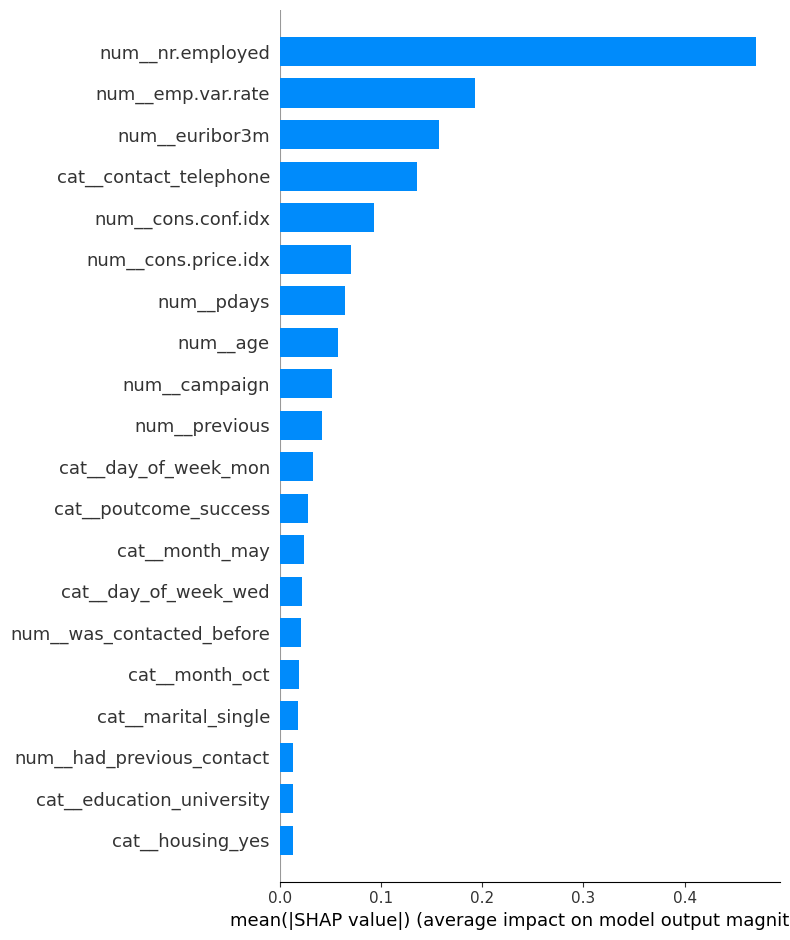

In [104]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

best_model = best_xgb_random

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP summary bar plot")
shap.summary_plot(shap_values, X_test_df, plot_type="bar")


SHAP summary plot


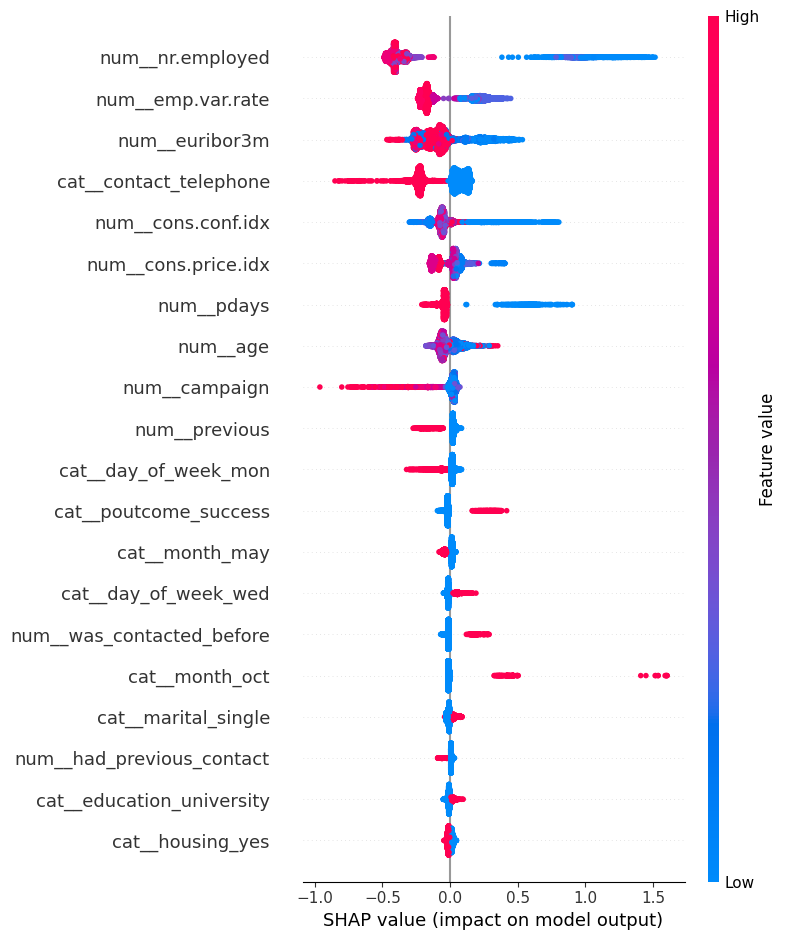

In [102]:
print("SHAP summary plot")
shap.summary_plot(shap_values, X_test_df)


Dependence plots


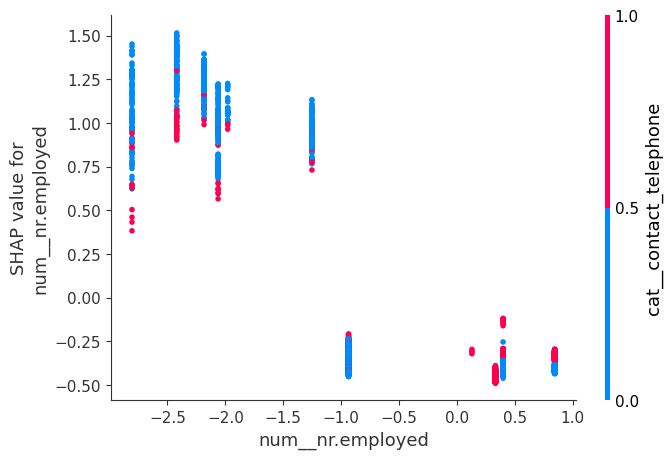

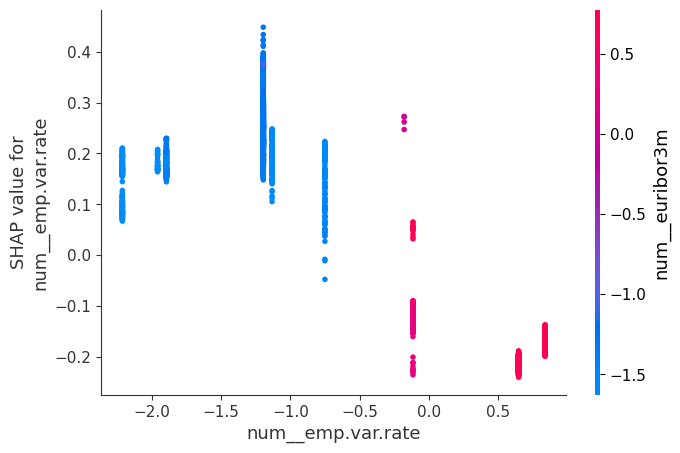

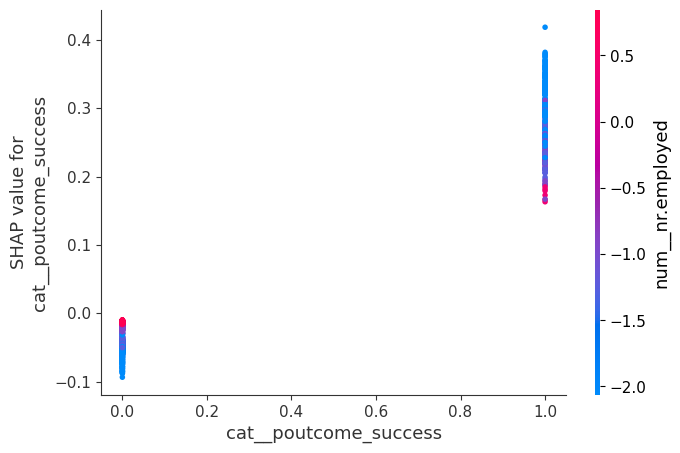

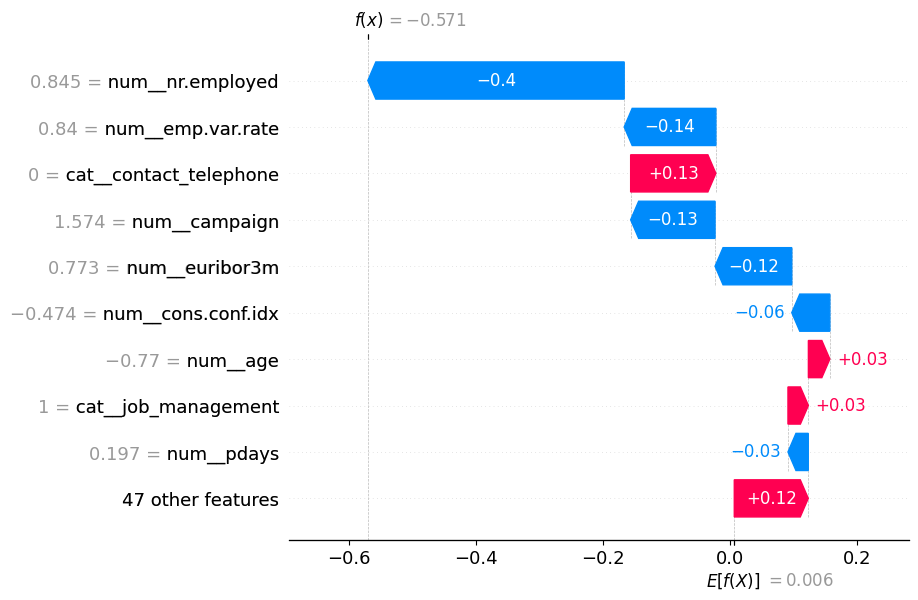

In [103]:
print("Dependence plots")
shap.dependence_plot("num__nr.employed", shap_values, X_test_df)
shap.dependence_plot("num__emp.var.rate", shap_values, X_test_df)
shap.dependence_plot("cat__poutcome_success", shap_values, X_test_df)

idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[idx],
        feature_names=X_test_df.columns
    )
)

SHAP analysis was performed to better understand how different features influence the model predictions.

The global feature importance plot shows that the most important features are nr.employed, emp.var.rate, and euribor3m.

From the SHAP summary plot, we can observe the direction of the impact. Higher values of nr.employed tend to decrease the probability of subscription, while lower values increase it. A similar pattern is observed for emp.var.rate and euribor3m,

The feature contact_telephone has a negative impact compared to cellular contact, meaning that customers contacted via telephone are less likely to subscribe.

The variable campaign shows that a higher number of contacts negatively affects the prediction, which aligns with previous EDA findings that repeated contact may reduce conversion probability.

The feature poutcome_success has a strong positive impact, confirming that customers who previously responded positively are more likely to subscribe again.

The dependence plot for emp.var.rate further confirms a non-linear relationship with the target, showing that the effect of this variable changes depending on its value.

The local explanation (force plot) illustrates how individual features contribute to a single prediction. In this case, macroeconomic features and campaign-related variables significantly decreased the probability of a positive outcome.

Overall, the SHAP analysis confirms that the model captures realistic and interpretable relationships, combining both customer history and macroeconomic indicators. The feature importance ranking is consistent with domain knowledge and can be considered reasonable from a common sense perspective.

**Error analysis**

In [107]:
y_pred = best_model.predict(X_test_processed)

error_df = X_test_df.copy()
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_pred

error_df['error_type'] = 'correct'

error_df.loc[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0), 'error_type'] = 'FN'  # false negative
error_df.loc[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1), 'error_type'] = 'FP'  # false positive

errors = error_df[error_df['error_type'] != 'correct']

print(errors['error_type'].value_counts())

error_type
FP    975
FN    315
Name: count, dtype: int64


In [110]:
errors.groupby('error_type').mean(numeric_only=True)

,num__age,num__campaign,num__pdays,num__previous,num__emp.var.rate,num__cons.price.idx,num__cons.conf.idx,num__euribor3m,num__nr.employed,num__was_contacted_before,num__had_previous_contact,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__marital_married,cat__marital_single,cat__education_high.school,cat__education_professional,cat__education_university,cat__default_yes,cat__housing_yes,cat__loan_yes,cat__contact_telephone,cat__month_aug,cat__month_dec,cat__month_jul,cat__month_jun,cat__month_mar,cat__month_may,cat__month_nov,cat__month_oct,cat__month_sep,cat__day_of_week_mon,cat__day_of_week_thu,cat__day_of_week_tue,cat__day_of_week_wed,cat__poutcome_nonexistent,cat__poutcome_success,cat__age_bin_31_40,cat__age_bin_41_50,cat__age_bin_51_60,cat__age_bin_60_plus,cat__job_group_entrepreneur,cat__job_group_housemaid,cat__job_group_retired,cat__job_group_self-employed,cat__job_group_student,cat__job_group_unemployed,cat__job_group_white_collar,y_true,y_pred
error_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FN,-0.07,0.10,0.18,-0.15,0.24,0.07,-0.18,0.21,0.28,-0.18,-0.15,0.27,0.04,0.01,0.07,0.03,0.04,0.11,0.02,0.17,0.03,0.58,0.28,0.23,0.14,0.28,0.00,0.55,0.12,0.33,0.15,0.00,0.25,0.10,0.00,0.39,0.10,0.00,0.00,0.16,0.23,0.19,0.25,0.91,0.00,0.44,0.24,0.16,0.00,0.04,0.01,0.03,0.04,0.02,0.03,0.46,1.00,0.00
FP,0.04,-0.27,-0.31,0.38,-1.45,-0.98,-0.05,-1.43,-1.41,0.31,0.38,0.11,0.03,0.02,0.07,0.11,0.04,0.07,0.06,0.15,0.03,0.50,0.39,0.23,0.12,0.38,0.00,0.57,0.13,0.10,0.12,0.02,0.05,0.11,0.05,0.24,0.05,0.07,0.05,0.24,0.21,0.17,0.17,0.73,0.08,0.31,0.16,0.13,0.10,0.03,0.02,0.11,0.04,0.06,0.03,0.53,0.00,1.00


In [112]:
display(error_df.columns)

Index(['num__age', 'num__campaign', 'num__pdays', 'num__previous',
       'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx',
       'num__euribor3m', 'num__nr.employed', 'num__was_contacted_before',
       'num__had_previous_contact', 'cat__job_blue-collar',
       'cat__job_entrepreneur', 'cat__job_housemaid', 'cat__job_management',
       'cat__job_retired', 'cat__job_self-employed', 'cat__job_services',
       'cat__job_student', 'cat__job_technician', 'cat__job_unemployed',
       'cat__marital_married', 'cat__marital_single',
       'cat__education_high.school', 'cat__education_professional',
       'cat__education_university', 'cat__default_yes', 'cat__housing_yes',
       'cat__loan_yes', 'cat__contact_telephone', 'cat__month_aug',
       'cat__month_dec', 'cat__month_jul', 'cat__month_jun', 'cat__month_mar',
       'cat__month_may', 'cat__month_nov', 'cat__month_oct', 'cat__month_sep',
       'cat__day_of_week_mon', 'cat__day_of_week_thu', 'cat__day_of_week_tue',

In [115]:
selected_cols = [col for col in errors.columns if 'job' in col or 'contact' in col]

for col in selected_cols[:5]:
    print("\n", col)
    print(errors.groupby('error_type')[col].mean())


 num__was_contacted_before
error_type
FN   -0.18
FP    0.31
Name: num__was_contacted_before, dtype: float64

 num__had_previous_contact
error_type
FN   -0.15
FP    0.38
Name: num__had_previous_contact, dtype: float64

 cat__job_blue-collar
error_type
FN   0.27
FP   0.11
Name: cat__job_blue-collar, dtype: float64

 cat__job_entrepreneur
error_type
FN   0.04
FP   0.03
Name: cat__job_entrepreneur, dtype: float64

 cat__job_housemaid
error_type
FN   0.01
FP   0.02
Name: cat__job_housemaid, dtype: float64


In [116]:
correct = error_df[error_df['error_type'] == 'correct']

print("Errors mean:")
print(errors.mean(numeric_only=True))

print("\nCorrect mean:")
print(correct.mean(numeric_only=True))

Errors mean:
num__age                        0.01
num__campaign                  -0.18
num__pdays                     -0.19
num__previous                   0.25
num__emp.var.rate              -1.04
num__cons.price.idx            -0.73
num__cons.conf.idx             -0.08
num__euribor3m                 -1.03
num__nr.employed               -1.00
num__was_contacted_before       0.19
num__had_previous_contact       0.25
cat__job_blue-collar            0.15
cat__job_entrepreneur           0.03
cat__job_housemaid              0.02
cat__job_management             0.07
cat__job_retired                0.09
cat__job_self-employed          0.04
cat__job_services               0.08
cat__job_student                0.05
cat__job_technician             0.16
cat__job_unemployed             0.03
cat__marital_married            0.52
cat__marital_single             0.36
cat__education_high.school      0.23
cat__education_professional     0.12
cat__education_university       0.36
cat__default_yes         

An error analysis was conducted to better understand the cases where the model makes incorrect predictions.

The analysis shows that false negatives (cases where the model predicts “no” but the actual result is “yes”) often occur for customers with weak historical signals, such as no previous successful contacts or limited interaction history. This suggests that the model struggles to identify potential positive responses when there is insufficient past information.
False positives (cases where the model predicts “yes” but the actual result is “no”) are often associated with customers who have multiple contacts during the campaign. This may indicate that repeated contact increases the model's confidence, even though in reality it may lead to customer fatigue and lower conversion rates.

Additionally, some errors are linked to “unknown” categories, which may introduce noise and reduce model performance.

Overall, the analysis highlights that the model performs well on strong signals but struggles in borderline cases.

**CONCLUSION**

In this project, a full machine learning pipeline for binary classification was developed, including exploratory data analysis, feature engineering, model training, evaluation, and interpretation.

The exploratory data analysis revealed several important patterns. Customer behavior is strongly influenced by both individual characteristics and external economic conditions. Features such as previous campaign outcome, number of contacts, and macroeconomic indicators showed a clear relationship with the target variable.

Several machine learning models were trained and evaluated, including Logistic Regression, k-Nearest Neighbors, Decision Tree, and XGBoost. Among them, XGBoost demonstrated the best performance in terms of ROC-AUC, while Logistic Regression provided more interpretable results.

Hyperparameter tuning using Randomized Search and Bayesian Optimization (Hyperopt) further improved the performance of the boosting model. Both approaches produced similar results, confirming the robustness of the solution.

Feature importance and SHAP analysis showed that macroeconomic variables (such as nr.employed, emp.var.rate, and euribor3m) have the strongest impact on predictions. Additionally, customer interaction features, such as previous campaign success and number of contacts, also play a significant role.

Error analysis revealed that the model struggles with borderline cases, particularly when there is limited historical information about the customer. It was also observed that excessive contact may negatively affect predictions, indicating potential customer fatigue.


Overall, the developed model provides a reliable and interpretable solution for predicting customer subscription behavior and can be effectively used in real-world applications.

